# Sale Forecasting -- LightGBM Time-Based Train/Val/Test (2025)

## Tiêu đề và mục tiêu bài toán

**Bài toán**: Dự báo doanh số bán hàng theo từng cặp `(location, item_id)`.

**Mô tả**:
- Dữ liệu giao dịch mua hàng (event "purchased") năm 2025.
- Dữ liệu event khác (view_item, add-to-cart) có thể bổ sung sau; notebook này chỉ dùng purchase.
- **Train data**: 2025, **Blind test**: tháng 1/2026.
- Output submission: bảng 3 cột `location`, `item_id`, `prediction`.
- Đánh giá trên các location có giao dịch, loại bỏ item có `sale_status = 0`.

**Metrics**:
| Metric | Mô tả |
|---|---|
| MAE quantity | Mean Absolute Error trên số lượng bán |
| **MAPE quantity** | **Mean Absolute Percentage Error trên số lượng (metric chính)** |
| MAE revenue | Mean Absolute Error trên doanh thu |
| MAPE revenue | Mean Absolute Percentage Error trên doanh thu |

## Chiến lược Train / Validation / Test theo thời gian

Notebook này sử dụng **rolling temporal samples** kết hợp **chia tập theo thời gian nghiêm ngặt**.

**Bước 1 -- Huấn luyện để chọn tham số (model selection):**
- `train_df_tune` gồm 3 rolling samples:
  - T1-T6 -> T7
  - T1-T7 -> T8
  - T1-T8 -> T9
- `val_df_tune` (tháng 10 làm validation):
  - T1-T9 -> T10
- Dùng early stopping trên tập October để chọn `best_iteration`.

**Bước 2 -- Huấn luyện lại với tham số tốt nhất:**
- `train_df_final` gồm 4 rolling samples:
  - T1-T6 -> T7
  - T1-T7 -> T8
  - T1-T8 -> T9
  - T1-T9 -> T10
- Huấn luyện với `num_boost_round = best_iteration` (không early stopping).

**Bước 3 -- Đánh giá cuối cùng trên tháng 11:**
- `test_df` (chỉ dùng 1 lần để báo cáo metric):
  - T1-T10 -> T11

**Ưu điểm:**
- Rolling sample tạo nhiều dòng huấn luyện hơn (nhiều ví dụ thời gian).
- Tháng 10 được giữ riêng để chọn tham số, không bị rò rỉ vào training.
- Tháng 11 hoàn toàn không tham gia huấn luyện hay chọn tham số.
- Phù hợp với bài toán dự báo hơn chia ngẫu nhiên.

**Quy tắc chống rò rỉ (Anti-leakage):**
- Với tháng mục tiêu `t`, features chỉ tính từ tháng 1 đến `t-1`.
- VD: mục tiêu T7 -> features T1-T6; mục tiêu T11 -> features T1-T10.

In [1]:
# Cài đặt thư viện cần thiết
import subprocess, sys
for pkg in ["lightgbm","polars","pyarrow","pandas","numpy","scikit-learn","matplotlib"]:
    subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])
print("Da cai dat xong cac thu vien.")

Da cai dat xong cac thu vien.


In [2]:
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import warnings, os, pathlib
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

ROOT = pathlib.Path(r"C:\Users\asus\Documents\HocTap\HK4\CS116 - Python Programming For ML\Pj-selling website")
RAW = ROOT / "raw_data"
OUT = ROOT / "Additional Doc" / "Đồ-Án"
OUT.mkdir(parents=True, exist_ok=True)

TXN_PATH = RAW / "transaction_full_2025.parquet"
ITEMS_PATH = RAW / "items.parquet"

print(f"Transaction file: {TXN_PATH}")
print(f"Items file: {ITEMS_PATH}")
print(f"Output folder: {OUT}")

Transaction file: C:\Users\asus\Documents\HocTap\HK4\CS116 - Python Programming For ML\Pj-selling website\raw_data\transaction_full_2025.parquet
Items file: C:\Users\asus\Documents\HocTap\HK4\CS116 - Python Programming For ML\Pj-selling website\raw_data\items.parquet
Output folder: C:\Users\asus\Documents\HocTap\HK4\CS116 - Python Programming For ML\Pj-selling website\Additional Doc\Đồ-Án


## Đọc dữ liệu và kiểm tra schema

In [3]:
items_df = pl.read_parquet(str(ITEMS_PATH))
print("Items schema:")
print(items_df.schema)
print(f"   Shape: {items_df.shape}")
print(f"   sale_status phan bo: {items_df['sale_status'].value_counts().sort('sale_status')}")

Items schema:
Schema({'item_id': String, 'price': Decimal(precision=38, scale=4), 'category_l1': String, 'category_l2': String, 'category_l3': String, 'category': String, 'brand': String, 'manufacturer': String, 'description': String, 'sale_status': Int32, 'size': String})
   Shape: (29823, 11)
   sale_status phan bo: shape: (2, 2)
┌─────────────┬───────┐
│ sale_status ┆ count │
│ ---         ┆ ---   │
│ i32         ┆ u32   │
╞═════════════╪═══════╡
│ 0           ┆ 22973 │
│ 1           ┆ 6850  │
└─────────────┴───────┘


In [4]:
txn_lazy = pl.scan_parquet(str(TXN_PATH))
print("Transaction schema:")
print(txn_lazy.schema)
txn_lazy.head(5).collect().to_pandas()

Transaction schema:
Schema({'bill_id': Int32, 'customer_id': Int32, 'item_id': String, 'price': Decimal(precision=38, scale=4), 'quantity': Int32, 'event_type': String, 'updated_date': Datetime(time_unit='us', time_zone=None), 'location_name': String})


,bill_id,customer_id,item_id,price,quantity,event_type,updated_date,location_name
0,137262467,6291331,6767000000002,285000.0000,1,Purchase,2025-04-12 12:52:41.910,QNG - 255 Quốc Lộ 1A
1,138193104,5505362,2265000000027,195000.0000,1,Purchase,2025-04-24 14:57:00.773,HCM - 88/4 Nguyễn Ảnh Thủ
2,138230425,7694873,6497000000004,312550.0000,1,Purchase,2025-04-24 20:35:40.027,BDU - 272 Đại Lộ Bình Dương
3,138235471,5837076,6587000000001,149000.0000,1,Purchase,2025-04-24 21:12:32.070,HCM - 703 Lê Hồng Phong
4,138239415,6781756,3880000000002,79000.0000,1,Purchase,2025-04-25 08:00:46.293,LDO - Quốc Lộ 20


## Tiền xử lý dữ liệu

**Các bước**:
1. Lọc chỉ event "Purchase" (case-insensitive).
2. Chuyển `updated_date` sang datetime, tạo cột `date` và `month`.
3. Tính `revenue = price * quantity`.
4. Loại bỏ tháng 12.
5. Join với items có `sale_status != 0`.
6. Đổi tên `location_name` -> `location`.

In [5]:
txn_processed = (
    txn_lazy
    .filter(pl.col("event_type").str.to_lowercase().str.contains("purchase"))
    .with_columns(pl.col("updated_date").cast(pl.Datetime))
    .with_columns([
        pl.col("updated_date").dt.date().alias("date"),
        pl.col("updated_date").dt.month().alias("month"),
        pl.col("updated_date").dt.year().alias("year"),
        (pl.col("price").cast(pl.Float64) * pl.col("quantity").cast(pl.Float64)).alias("revenue"),
    ])
    .filter((pl.col("month") < 12) & (pl.col("year") == 2025))
    .rename({"location_name": "location"})
    .with_columns(pl.col("item_id").cast(pl.Utf8))
)

items_active = (
    items_df
    .filter(pl.col("sale_status") != 0)
    .select("item_id", "price", "category_l1", "category_l2", "category_l3",
            "category", "brand", "manufacturer", "size")
    .with_columns(pl.col("item_id").cast(pl.Utf8))
    .rename({"price": "item_price"})
)
print(f"Items active (sale_status != 0): {items_active.shape[0]:,} items")

txn_clean = (
    txn_processed
    .join(items_active.lazy(), on="item_id", how="inner")
    .collect()
)
print(f"Transactions sau tien xu ly: {txn_clean.shape[0]:,} dong")
print(f"   Pham vi: {txn_clean['date'].min()} -> {txn_clean['date'].max()}")
print(f"   So thang: {txn_clean['month'].unique().sort()}")
print(f"   So location: {txn_clean['location'].n_unique()}")
print(f"   So item_id: {txn_clean['item_id'].n_unique()}")

Items active (sale_status != 0): 6,850 items
Transactions sau tien xu ly: 32,142,167 dong
   Pham vi: 2025-01-01 -> 2025-11-30
   So thang: shape: (11,)
Series: 'month' [i8]
[
	1
	2
	3
	4
	5
	…
	7
	8
	9
	10
	11
]
   So location: 987
   So item_id: 5662


In [6]:
# Tong hop theo (location, item_id, month)
monthly = (
    txn_clean.lazy()
    .group_by(["location", "item_id", "month"])
    .agg([
        pl.col("quantity").sum().alias("qty"),
        pl.col("revenue").sum().alias("rev"),
        pl.col("date").n_unique().alias("active_days"),
        pl.col("bill_id").n_unique().alias("num_bills"),
        pl.col("customer_id").n_unique().alias("num_customers"),
        pl.col("price").cast(pl.Float64).mean().alias("avg_price"),
        pl.col("price").cast(pl.Float64).last().alias("last_price"),
    ])
    .collect()
)
print(f"Bang monthly: {monthly.shape[0]:,} dong, {monthly.shape[1]} cot")
monthly.head(5).to_pandas()

Bang monthly: 8,696,539 dong, 10 cot


,location,item_id,month,qty,rev,active_days,num_bills,num_customers,avg_price,last_price
0,AGI - 110 Tôn Đức Thắng,4004000000045,8,1,159812.2214,1,1,1,159812.22140,159812.2214
1,DNA - 36 Nguyễn Đức Trung,6034000000337,7,2,172909.3087,2,2,2,86454.65435,113909.3087
2,CTO - 50B Hùng Vương,2155000000110,5,5,733875.0000,5,5,5,146775.00000,149000.0000
3,TNI - 339 Hoàng Lê Kha,3951000000423,8,2,183732.4841,2,2,2,91866.24205,94732.4841
4,BDI - 256 Ngô Gia Tự,1535000000002,10,2,51800.0000,2,2,2,25900.00000,25900.0000


## Feature Engineering -- hàm `build_features`

Hàm `build_features(monthly, items_active, history_end_month, target_month)` tạo một bảng supervised:
- Features tính từ tháng 1 đến `history_end_month`.
- Target là tổng số lượng/doanh thu của `target_month`.
- Mỗi dòng là một bộ `(location, item_id, target_month)`.

Quy tắc: features chỉ dùng dữ liệu **trước** tháng mục tiêu.

In [7]:
def build_features(monthly_all, items_act, history_end_month, target_month):
    """Tao bang supervised. Features chi dung thang 1 -> history_end_month."""
    monthly_hist = monthly_all.filter(pl.col("month") <= history_end_month)
    monthly_target = monthly_all.filter(pl.col("month") == target_month)
    skeleton = pl.concat([
        monthly_hist.select("location","item_id").unique(),
        monthly_target.select("location","item_id").unique()
    ]).unique()

    # Qty pivot
    qp = (monthly_hist.lazy().select("location","item_id","month","qty").collect()
          .pivot(on="month", index=["location","item_id"], values="qty").fill_null(0))
    rn = {str(m): f"qty_m{m:02d}" for m in range(1, history_end_month+1)}
    qp = qp.rename({k:v for k,v in rn.items() if k in qp.columns})
    for m in range(1, 11):
        c = f"qty_m{m:02d}"
        if c not in qp.columns: qp = qp.with_columns(pl.lit(0).alias(c))

    # Rev pivot
    rp = (monthly_hist.lazy().select("location","item_id","month","rev").collect()
          .pivot(on="month", index=["location","item_id"], values="rev").fill_null(0))
    rn2 = {str(m): f"rev_m{m:02d}" for m in range(1, history_end_month+1)}
    rp = rp.rename({k:v for k,v in rn2.items() if k in rp.columns})
    for m in range(1, 11):
        c = f"rev_m{m:02d}"
        if c not in rp.columns: rp = rp.with_columns(pl.lit(0.0).alias(c))

    ft = skeleton.clone()
    ft = ft.join(qp, on=["location","item_id"], how="left").fill_null(0)
    rc = [c for c in rp.columns if c.startswith("rev_m")]
    ft = ft.join(rp.select(["location","item_id"]+rc), on=["location","item_id"], how="left").fill_null(0)

    hem = history_end_month
    # Recent qty
    ft = ft.with_columns([
        pl.col(f"qty_m{hem:02d}").alias("qty_last_1m"),
        (pl.col(f"qty_m{max(hem-1,1):02d}").alias("qty_last_2m") if hem>=2 else pl.lit(0).alias("qty_last_2m")),
        (pl.col(f"qty_m{max(hem-2,1):02d}").alias("qty_last_3m") if hem>=3 else pl.lit(0).alias("qty_last_3m")),
    ])
    # Rolling
    l3q = [f"qty_m{max(hem-i,1):02d}" for i in range(3)] if hem>=3 else [f"qty_m{m:02d}" for m in range(1,hem+1)]
    l6q = [f"qty_m{max(hem-i,1):02d}" for i in range(6)] if hem>=6 else [f"qty_m{m:02d}" for m in range(1,hem+1)]
    l3r = [f"rev_m{max(hem-i,1):02d}" for i in range(3)] if hem>=3 else [f"rev_m{m:02d}" for m in range(1,hem+1)]
    l6r = [f"rev_m{max(hem-i,1):02d}" for i in range(6)] if hem>=6 else [f"rev_m{m:02d}" for m in range(1,hem+1)]
    ft = ft.with_columns([
        (pl.sum_horizontal(*l3q)/len(l3q)).alias("qty_rolling_3m"),
        (pl.sum_horizontal(*l6q)/len(l6q)).alias("qty_rolling_6m"),
        (pl.sum_horizontal(*l3r)/len(l3r)).alias("rev_rolling_3m"),
        (pl.sum_horizontal(*l6r)/len(l6r)).alias("rev_rolling_6m"),
    ])
    # Aggregate
    aq = [f"qty_m{m:02d}" for m in range(1,hem+1)]
    ar = [f"rev_m{m:02d}" for m in range(1,hem+1)]
    nh = len(aq)
    ft = ft.with_columns([
        pl.sum_horizontal(aq).alias("qty_total_hist"),
        (pl.sum_horizontal(aq)/float(nh)).alias("qty_mean_hist"),
        pl.concat_list(aq).list.eval(pl.element().std()).list.first().alias("qty_std_hist"),
        pl.max_horizontal(aq).alias("qty_max_hist"),
        pl.sum_horizontal(ar).alias("rev_total_hist"),
        (pl.sum_horizontal(ar)/float(nh)).alias("rev_mean_hist"),
        pl.concat_list(ar).list.eval(pl.element().std()).list.first().alias("rev_std_hist"),
        pl.max_horizontal(ar).alias("rev_max_hist"),
    ])
    # Activity
    ft = ft.with_columns([pl.sum_horizontal([pl.col(c)>0 for c in aq]).alias("months_active_hist")])
    ft = ft.with_columns([(nh-pl.col("months_active_hist")).alias("zero_months_hist")])
    act = (monthly_hist.lazy().group_by(["location","item_id"]).agg([
        pl.col("active_days").sum().alias("active_days_hist"),
        pl.col("num_bills").sum().alias("num_bills_hist"),
        pl.col("num_customers").sum().alias("num_customers_hist"),
        pl.col("avg_price").mean().alias("avg_price_hist"),
        pl.col("last_price").last().alias("last_known_price"),
    ]).collect())
    ft = ft.join(act, on=["location","item_id"], how="left")
    # Price
    ft = ft.join(items_act.select("item_id", pl.col("item_price").cast(pl.Float64).alias("price_ref")),
                 on="item_id", how="left")
    ft = ft.with_columns([pl.coalesce("last_known_price","avg_price_hist","price_ref").alias("price_ref_final")])
    # Trend
    if hem>=2:
        ft = ft.with_columns([(pl.col(f"qty_m{hem:02d}")-pl.col(f"qty_m{hem-1:02d}")).alias("trend_qty_last_1_2")])
    else:
        ft = ft.with_columns(pl.lit(0).alias("trend_qty_last_1_2"))
    ft = ft.with_columns([(pl.col("qty_rolling_3m")-pl.col("qty_rolling_6m")).alias("trend_qty_r3_r6")])
    # Metadata
    mc = ["item_id","category_l1","category_l2","category_l3","category","brand","manufacturer","size"]
    ft = ft.join(items_act.select([c for c in mc if c in items_act.columns]), on="item_id", how="left")
    # Global
    gi = monthly_hist.lazy().group_by("item_id").agg([
        pl.col("qty").sum().alias("item_global_qty_hist"),
        pl.col("rev").sum().alias("item_global_rev_hist")]).collect()
    gl = monthly_hist.lazy().group_by("location").agg([
        pl.col("qty").sum().alias("loc_global_qty_hist"),
        pl.col("rev").sum().alias("loc_global_rev_hist")]).collect()
    ft = ft.join(gi, on="item_id", how="left").fill_null(0)
    ft = ft.join(gl, on="location", how="left").fill_null(0)
    # Temporal context
    ft = ft.with_columns([
        pl.lit(target_month).cast(pl.Int32).alias("target_month"),
        pl.lit(history_end_month).cast(pl.Int32).alias("history_end_month"),
        pl.lit(nh).cast(pl.Int32).alias("history_months_count"),
    ])
    # Target
    labels = monthly_target.lazy().group_by(["location","item_id"]).agg([
        pl.col("qty").sum().alias("y_qty"),
        pl.col("rev").sum().alias("y_revenue")]).collect()
    ft = ft.join(labels, on=["location","item_id"], how="left")
    ft = ft.with_columns([pl.col("y_qty").fill_null(0).alias("y_qty"),
                          pl.col("y_revenue").fill_null(0.0).alias("y_revenue")])
    if "price_ref" in ft.columns and "price_ref_final" in ft.columns:
        ft = ft.drop("price_ref").rename({"price_ref_final":"price_ref"})
    return ft

print("Ham build_features da duoc dinh nghia.")

Ham build_features da duoc dinh nghia.


## Bước 1 -- Tạo tập huấn luyện và validation để chọn tham số

- `train_df_tune`: T7, T8, T9 (tháng 10 **không** nằm trong tập này).
- `val_df_tune`: T10 (dùng để chọn best_iteration qua early stopping).

In [8]:
# === BUOC 1: TAO TAP HUAN LUYEN VA VALIDATION ===
tune_configs = [(6,7),(7,8),(8,9)]
train_parts_tune = []
for hem, tm in tune_configs:
    print(f"  train_tune: history T1-T{hem} -> target T{tm} ...")
    part = build_features(monthly, items_active, hem, tm)
    print(f"    -> {part.shape[0]:,} dong")
    train_parts_tune.append(part)

# Dam bao cung cot
all_cols = train_parts_tune[0].columns
for i, p in enumerate(train_parts_tune):
    for c in all_cols:
        if c not in p.columns:
            train_parts_tune[i] = p.with_columns(pl.lit(0).alias(c))
    train_parts_tune[i] = train_parts_tune[i].select(all_cols)

train_df_tune = pl.concat(train_parts_tune)
print(f"\ntrain_df_tune: {train_df_tune.shape[0]:,} dong")
print(f"  target_month: {train_df_tune['target_month'].value_counts().sort('target_month')}")

# Validation: T10
print("\n  val_tune: history T1-T9 -> target T10 ...")
val_df_tune = build_features(monthly, items_active, 9, 10)
for c in all_cols:
    if c not in val_df_tune.columns:
        val_df_tune = val_df_tune.with_columns(pl.lit(0).alias(c))
val_df_tune = val_df_tune.select(all_cols)
print(f"val_df_tune: {val_df_tune.shape[0]:,} dong")

  train_tune: history T1-T6 -> target T7 ...
    -> 1,401,796 dong
  train_tune: history T1-T7 -> target T8 ...
    -> 1,559,805 dong
  train_tune: history T1-T8 -> target T9 ...
    -> 1,694,005 dong

train_df_tune: 4,655,606 dong
  target_month: shape: (3, 2)
┌──────────────┬─────────┐
│ target_month ┆ count   │
│ ---          ┆ ---     │
│ i32          ┆ u32     │
╞══════════════╪═════════╡
│ 7            ┆ 1401796 │
│ 8            ┆ 1559805 │
│ 9            ┆ 1694005 │
└──────────────┴─────────┘

  val_tune: history T1-T9 -> target T10 ...
val_df_tune: 1,835,050 dong


## Huấn luyện LightGBM -- chọn tham số với early stopping trên tháng 10

In [9]:
# === CHUAN BI DU LIEU ===
id_cols = ["location", "item_id"]
target_col = "y_qty"
target_rev = "y_revenue"
drop_cols = id_cols + [target_col, target_rev]

train_tune_pd = train_df_tune.to_pandas()
val_tune_pd = val_df_tune.to_pandas()

feature_cols = [c for c in train_tune_pd.columns if c not in drop_cols]
cat_cols = ["category_l1","category_l2","category_l3","category","brand","manufacturer","size"]
cat_cols = [c for c in cat_cols if c in feature_cols]
num_cols = [c for c in feature_cols if c not in cat_cols]

# Encode categorical -- fit tren train_tune, transform val_tune
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
train_tune_pd[cat_cols] = enc.fit_transform(train_tune_pd[cat_cols].astype(str).fillna("__NA__"))
val_tune_pd[cat_cols] = enc.transform(val_tune_pd[cat_cols].astype(str).fillna("__NA__"))
train_tune_pd[num_cols] = train_tune_pd[num_cols].fillna(0)
val_tune_pd[num_cols] = val_tune_pd[num_cols].fillna(0)

X_tune = train_tune_pd[feature_cols]
y_tune = train_tune_pd[target_col]
X_val = val_tune_pd[feature_cols]
y_val = val_tune_pd[target_col]
y_val_rev = val_tune_pd[target_rev]

print(f"X_tune: {X_tune.shape}, X_val: {X_val.shape}")
print(f"Feature cols: {len(feature_cols)} ({len(num_cols)} numeric + {len(cat_cols)} categorical)")

X_tune: (4655606, 59), X_val: (1835050, 59)
Feature cols: 59 (52 numeric + 7 categorical)


In [10]:
# === HUAN LUYEN VONG 1: CHON THAM SO ===
y_tune_log = np.log1p(y_tune)
y_val_log = np.log1p(y_val)

dtrain_tune = lgb.Dataset(X_tune, label=y_tune_log, categorical_feature=cat_cols, free_raw_data=False)
dval_tune = lgb.Dataset(X_val, label=y_val_log, reference=dtrain_tune, categorical_feature=cat_cols, free_raw_data=False)

params = {
    "objective": "regression",
    "metric": "mae",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "seed": SEED,
    "n_jobs": -1,
}

model_tune = lgb.train(
    params, dtrain_tune,
    num_boost_round=1500,
    valid_sets=[dtrain_tune, dval_tune],
    valid_names=["train","val_oct"],
    callbacks=[lgb.log_evaluation(100), lgb.early_stopping(50)],
)
best_iter = model_tune.best_iteration
print(f"\nBest iteration (early stopping tren T10): {best_iter}")

Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.370428	val_oct's l1: 0.364447
[200]	train's l1: 0.362562	val_oct's l1: 0.359515
[300]	train's l1: 0.359709	val_oct's l1: 0.358532
[400]	train's l1: 0.357996	val_oct's l1: 0.357957
[500]	train's l1: 0.356737	val_oct's l1: 0.357642
[600]	train's l1: 0.355737	val_oct's l1: 0.357453
[700]	train's l1: 0.354823	val_oct's l1: 0.357259
[800]	train's l1: 0.354192	val_oct's l1: 0.357159
[900]	train's l1: 0.353481	val_oct's l1: 0.357045
Early stopping, best iteration is:
[911]	train's l1: 0.353387	val_oct's l1: 0.356998

Best iteration (early stopping tren T10): 911


## Đánh giá validation trên tháng 10

In [11]:
# === DANH GIA TREN THANG 10 (VALIDATION) ===
def compute_metrics(actual_qty, pred_qty, actual_rev, pred_rev):
    mae_q = mean_absolute_error(actual_qty, pred_qty)
    mask_q = actual_qty > 0
    mape_q = np.mean(np.abs(actual_qty[mask_q]-pred_qty[mask_q])/actual_qty[mask_q]) if mask_q.sum()>0 else np.nan
    mae_r = mean_absolute_error(actual_rev, pred_rev)
    mask_r = actual_rev > 0
    mape_r = np.mean(np.abs(actual_rev[mask_r]-pred_rev[mask_r])/actual_rev[mask_r]) if mask_r.sum()>0 else np.nan
    return mae_q, mape_q, mae_r, mape_r

pred_val_log = model_tune.predict(X_val, num_iteration=best_iter)
pred_val_qty = np.clip(np.expm1(pred_val_log), 0, None)
pr_val = val_tune_pd["price_ref"].values if "price_ref" in val_tune_pd.columns else np.ones(len(pred_val_qty))
pred_val_rev = pred_val_qty * np.where(np.isnan(pr_val)|(pr_val==0), 1.0, pr_val)

act_val_qty = y_val.values
act_val_rev = y_val_rev.values
mae_q_val, mape_q_val, mae_r_val, mape_r_val = compute_metrics(act_val_qty, pred_val_qty, act_val_rev, pred_val_rev)

print("="*55)
print("  VALIDATION METRICS (Thang 10 -- chon tham so)")
print("="*55)
print(f"  MAE  quantity  : {mae_q_val:.4f}")
print(f"  MAPE quantity  : {mape_q_val:.4f}  (metric chinh)")
print(f"  MAE  revenue   : {mae_r_val:.4f}")
print(f"  MAPE revenue   : {mape_r_val:.4f}")
print("="*55)

  VALIDATION METRICS (Thang 10 -- chon tham so)
  MAE  quantity  : 1.8081
  MAPE quantity  : 0.5957  (metric chinh)
  MAE  revenue   : 232298.1615
  MAPE revenue   : 0.6435


## Bước 2 -- Huấn luyện lại với tham số tốt nhất

Ghép thêm tháng 10 vào tập huấn luyện, dùng `best_iteration` đã chọn.

In [12]:
# === BUOC 2: HUAN LUYEN LAI VOI THAM SO TOT NHAT ===
final_configs = [(6,7),(7,8),(8,9),(9,10)]
train_parts_final = []
for hem, tm in final_configs:
    print(f"  train_final: T1-T{hem} -> T{tm} ...")
    part = build_features(monthly, items_active, hem, tm)
    print(f"    -> {part.shape[0]:,} dong")
    train_parts_final.append(part)

for i, p in enumerate(train_parts_final):
    for c in all_cols:
        if c not in p.columns:
            train_parts_final[i] = p.with_columns(pl.lit(0).alias(c))
    train_parts_final[i] = train_parts_final[i].select(all_cols)

train_df_final = pl.concat(train_parts_final)
print(f"\ntrain_df_final: {train_df_final.shape[0]:,} dong")

# Chuyen sang pandas va encode
train_final_pd = train_df_final.to_pandas()
train_final_pd[cat_cols] = enc.transform(train_final_pd[cat_cols].astype(str).fillna("__NA__"))
train_final_pd[num_cols] = train_final_pd[num_cols].fillna(0)

X_final = train_final_pd[feature_cols]
y_final_log = np.log1p(train_final_pd[target_col])

dtrain_final = lgb.Dataset(X_final, label=y_final_log, categorical_feature=cat_cols, free_raw_data=False)

model_final = lgb.train(
    params, dtrain_final,
    num_boost_round=best_iter,
    valid_sets=[dtrain_final],
    valid_names=["train"],
    callbacks=[lgb.log_evaluation(100)],
)
print(f"\nHuan luyen lai xong voi {best_iter} rounds.")

  train_final: T1-T6 -> T7 ...
    -> 1,401,796 dong
  train_final: T1-T7 -> T8 ...
    -> 1,559,805 dong
  train_final: T1-T8 -> T9 ...
    -> 1,694,005 dong
  train_final: T1-T9 -> T10 ...
    -> 1,835,050 dong

train_df_final: 6,490,656 dong
[100]	train's l1: 0.365583
[200]	train's l1: 0.357525
[300]	train's l1: 0.354504
[400]	train's l1: 0.352771
[500]	train's l1: 0.351558
[600]	train's l1: 0.350658
[700]	train's l1: 0.349871
[800]	train's l1: 0.349213
[900]	train's l1: 0.348578

Huan luyen lai xong voi 911 rounds.


## Bước 3 -- Đánh giá cuối cùng trên tháng 11 (Internal Test)

Tháng 11 chưa từng được dùng trong huấn luyện hay chọn tham số.

In [13]:
# === TAO TAP TEST (THANG 11) ===
print("test: T1-T10 -> T11 ...")
test_df = build_features(monthly, items_active, 10, 11)
for c in all_cols:
    if c not in test_df.columns:
        test_df = test_df.with_columns(pl.lit(0).alias(c))
test_df = test_df.select(all_cols)
print(f"test_df: {test_df.shape[0]:,} dong")

test_pd = test_df.to_pandas()
test_pd[cat_cols] = enc.transform(test_pd[cat_cols].astype(str).fillna("__NA__"))
test_pd[num_cols] = test_pd[num_cols].fillna(0)

X_test = test_pd[feature_cols]
y_test = test_pd[target_col].values
y_test_rev = test_pd[target_rev].values

pred_test_log = model_final.predict(X_test, num_iteration=best_iter)
pred_test_qty = np.clip(np.expm1(pred_test_log), 0, None)
pr_test = test_pd["price_ref"].values if "price_ref" in test_pd.columns else np.ones(len(pred_test_qty))
pred_test_rev = pred_test_qty * np.where(np.isnan(pr_test)|(pr_test==0), 1.0, pr_test)

mae_q_test, mape_q_test, mae_r_test, mape_r_test = compute_metrics(y_test, pred_test_qty, y_test_rev, pred_test_rev)

print("="*55)
print("  FINAL TEST METRICS (Thang 11 -- bao cao cuoi)")
print("="*55)
print(f"  MAE  quantity  : {mae_q_test:.4f}")
print(f"  MAPE quantity  : {mape_q_test:.4f}  (metric chinh)")
print(f"  MAE  revenue   : {mae_r_test:.4f}")
print(f"  MAPE revenue   : {mape_r_test:.4f}")
print("="*55)

test: T1-T10 -> T11 ...
test_df: 2,018,248 dong
  FINAL TEST METRICS (Thang 11 -- bao cao cuoi)
  MAE  quantity  : 1.7375
  MAPE quantity  : 0.5887  (metric chinh)
  MAE  revenue   : 222491.9789
  MAPE revenue   : 0.6331


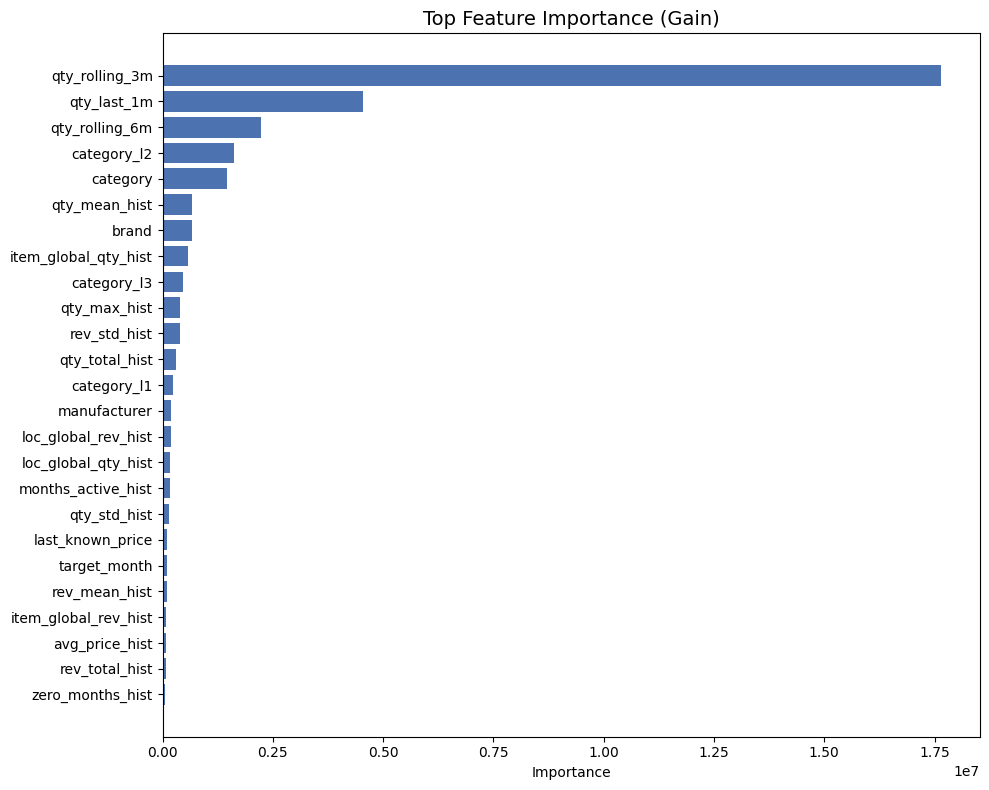

,feature,importance
23,qty_rolling_3m,1.764756e+07
20,qty_last_1m,4.542430e+06
24,qty_rolling_6m,2.220288e+06
46,category_l2,1.610290e+06
48,category,1.451497e+06
28,qty_mean_hist,6.754480e+05
49,brand,6.663692e+05
52,item_global_qty_hist,5.764281e+05
47,category_l3,4.563298e+05
30,qty_max_hist,3.927777e+05


In [14]:
# Feature importance (mo hinh cuoi)
fi = pd.DataFrame({"feature":feature_cols,"importance":model_final.feature_importance(importance_type="gain")})
fi = fi.sort_values("importance",ascending=False)
plt.figure(figsize=(10,8))
top_n = min(25,len(fi))
plt.barh(fi["feature"].head(top_n).values[::-1], fi["importance"].head(top_n).values[::-1], color="#4C72B0")
plt.title("Top Feature Importance (Gain)", fontsize=14)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
fi.head(20)

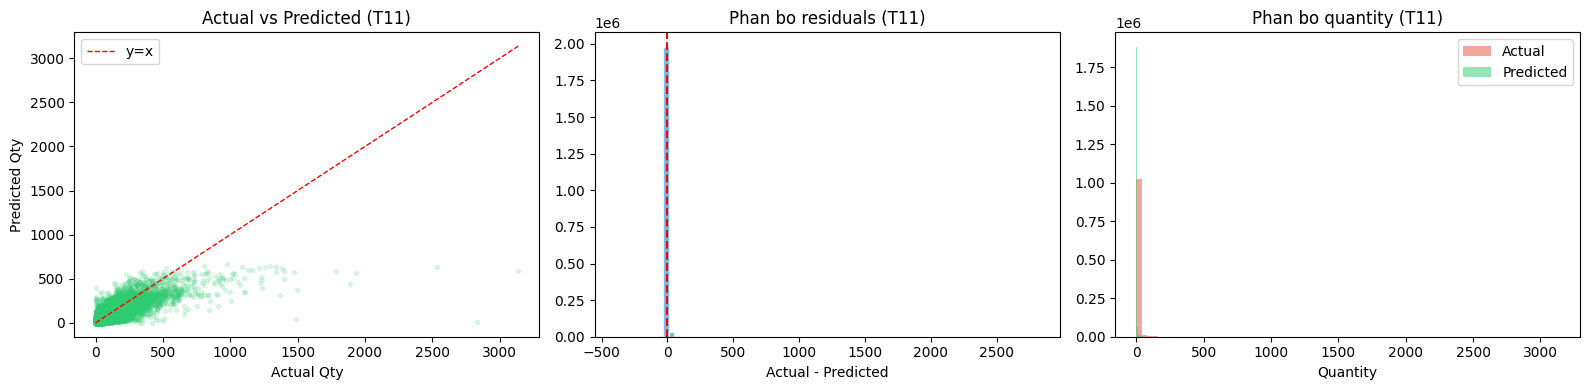

In [15]:
# Bieu do phan bo du doan (thang 11)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ax = axes[0]
ax.scatter(y_test, pred_test_qty, alpha=0.15, s=8, color="#2ecc71")
mx = max(y_test.max(), pred_test_qty.max())
ax.plot([0,mx],[0,mx],"r--",lw=1,label="y=x")
ax.set_xlabel("Actual Qty"); ax.set_ylabel("Predicted Qty")
ax.set_title("Actual vs Predicted (T11)"); ax.legend()
ax = axes[1]
residuals = y_test - pred_test_qty
ax.hist(residuals, bins=80, color="#3498db", alpha=0.7, edgecolor="white")
ax.axvline(0, color="red", ls="--")
ax.set_title("Phan bo residuals (T11)"); ax.set_xlabel("Actual - Predicted")
ax = axes[2]
ax.hist(y_test[y_test>0], bins=80, alpha=0.5, label="Actual", color="#e74c3c")
ax.hist(pred_test_qty[pred_test_qty>0], bins=80, alpha=0.5, label="Predicted", color="#2ecc71")
ax.set_title("Phan bo quantity (T11)"); ax.legend(); ax.set_xlabel("Quantity")
plt.tight_layout(); plt.show()

## Lưu kết quả

In [16]:
# === LUU KET QUA ===
# 1. October validation predictions
val_out = pd.DataFrame({
    "location": val_tune_pd["location"].values,
    "item_id": val_tune_pd["item_id"].values,
    "target_month": 10,
    "actual_qty": act_val_qty,
    "pred_qty": np.round(pred_val_qty, 4),
    "actual_revenue": act_val_rev,
    "pred_revenue": np.round(pred_val_rev, 4),
})
val_out.to_csv(str(OUT/"lightgbm_time_validation_oct_predictions.csv"), index=False)
print(f"Da luu: lightgbm_time_validation_oct_predictions.csv ({val_out.shape[0]:,} dong)")

# 2. November test predictions
test_out = pd.DataFrame({
    "location": test_pd["location"].values,
    "item_id": test_pd["item_id"].values,
    "target_month": 11,
    "actual_qty": y_test,
    "pred_qty": np.round(pred_test_qty, 4),
    "actual_revenue": y_test_rev,
    "pred_revenue": np.round(pred_test_rev, 4),
})
test_out.to_csv(str(OUT/"lightgbm_time_test_nov_predictions.csv"), index=False)
print(f"Da luu: lightgbm_time_test_nov_predictions.csv ({test_out.shape[0]:,} dong)")

# 3. Metrics
metrics_rows = [
    {"split":"validation_oct","metric":"MAE_quantity","value":mae_q_val,"note":""},
    {"split":"validation_oct","metric":"MAPE_quantity","value":mape_q_val,"note":"metric chinh"},
    {"split":"validation_oct","metric":"MAE_revenue","value":mae_r_val,"note":""},
    {"split":"validation_oct","metric":"MAPE_revenue","value":mape_r_val,"note":""},
    {"split":"test_nov","metric":"MAE_quantity","value":mae_q_test,"note":""},
    {"split":"test_nov","metric":"MAPE_quantity","value":mape_q_test,"note":"metric chinh"},
    {"split":"test_nov","metric":"MAE_revenue","value":mae_r_test,"note":""},
    {"split":"test_nov","metric":"MAPE_revenue","value":mape_r_test,"note":""},
]
pd.DataFrame(metrics_rows).to_csv(str(OUT/"lightgbm_time_split_metrics.csv"), index=False)
print(f"Da luu: lightgbm_time_split_metrics.csv")

Da luu: lightgbm_time_validation_oct_predictions.csv (1,835,050 dong)
Da luu: lightgbm_time_test_nov_predictions.csv (2,018,248 dong)
Da luu: lightgbm_time_split_metrics.csv


In [17]:
# === TOM TAT ===
print("="*60)
print("  TOM TAT -- LightGBM Time-Based Train/Val/Test")
print("="*60)
print(f"  Train (tune) : T7+T8+T9           -> {X_tune.shape[0]:,} dong")
print(f"  Val (tune)   : T10                -> {X_val.shape[0]:,} dong")
print(f"  Train (final): T7+T8+T9+T10       -> {X_final.shape[0]:,} dong")
print(f"  Test         : T11                -> {X_test.shape[0]:,} dong")
print(f"  Features     : {len(feature_cols)}")
print(f"  Best iter    : {best_iter}")
print(f"  -------------------------------------------")
print(f"  [Val T10]  MAPE qty : {mape_q_val:.4f}")
print(f"  [Val T10]  MAPE rev : {mape_r_val:.4f}")
print(f"  [Test T11] MAPE qty : {mape_q_test:.4f}  (metric chinh)")
print(f"  [Test T11] MAPE rev : {mape_r_test:.4f}")
print("="*60)

  TOM TAT -- LightGBM Time-Based Train/Val/Test
  Train (tune) : T7+T8+T9           -> 4,655,606 dong
  Val (tune)   : T10                -> 1,835,050 dong
  Train (final): T7+T8+T9+T10       -> 6,490,656 dong
  Test         : T11                -> 2,018,248 dong
  Features     : 59
  Best iter    : 911
  -------------------------------------------
  [Val T10]  MAPE qty : 0.5957
  [Val T10]  MAPE rev : 0.6435
  [Test T11] MAPE qty : 0.5887  (metric chinh)
  [Test T11] MAPE rev : 0.6331
